In [1]:
# Window
from IPython.display import display, HTML
display(HTML("<style>.container { width:90% !important; }</style>"))
display(HTML("<style>.output_result { width:90% !important; }</style>"))

<div class="alert alert-block alert-danger">
These notebooks are better visualized using codefolding from Jupyter
    <a href=\"https://jupyter-contrib-nbextensions.readthedocs.io/en/latest/\">extensions</a>.
    
This code was built using `NumPy: 2.2.5`, `SciPy: 1.15.1`, `SymPy: 1.13.3`.
</div>

In this notebook we test the first deflation technique from [[1]](https://arxiv.org/pdf/2407.06834).

[1] Andrés Miniguano-Trujillo, John William Pearson, Benjamin D Goddard (2025). **Efficient nonlocal linear image denoising: Bilevel optimization with Nonequispaced Fast Fourier Transform and matrix-free preconditioning**. Accepted at SIAM journal on Imaging Sciences. arXiv:2407.06834.

In [1]:
# Libraries
import numpy as np
import scipy.sparse as sp
import matplotlib.pyplot as plt

from EigenDeflation import *

In [2]:
np.set_printoptions(linewidth=180, precision = 2)

# Change of basis

<div class="alert alert-block alert-success">
Consider the hermitian matrix $A \in \mathbb{H}_n(\mathbb{F})$ with an eigenpair $(\lambda,\mathbf{v})$. We can build a deflation $Q \in \mathcal{M}_n(\mathbb{F})$ based on $\mathbf{v}$ such that the matrix $\mathsf{A}_{Q} = Q^{-1} A Q$ has a block-structure that isolates $\lambda$. In what follows, we build a quick example that computes the action of $Q = Q(\mathbf{v})$, its inverse, and verifies the block argument for a specific instance.
</div>

Set seed for random generator:

In [3]:
rng = np.random.default_rng(seed=2025)

Generate a random matrix:

In [4]:
n = 100
A = rng.normal(0.0, 10, (n,n))
A = np.tril(A) + np.tril(A, -1).T    # Guarantee all entries are normal 𝐍(0,10)

Visualise the spectrum of $A$ (this step can be avoided for large values of $n$):

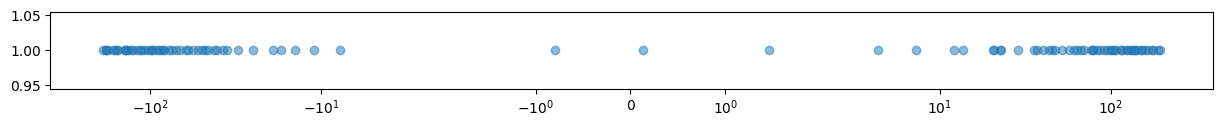

In [5]:
Λ = np.linalg.eigvalsh(A)
plt.figure(figsize=(15,1));    plt.plot( Λ, np.ones(n), 'o', alpha = 0.5 );    plt.xscale('symlog');    plt.show()

Let us find the eigenpair associated with the smallest eigenvalue of $A$:

In [6]:
Λ_partial, 𝐕 = sp.linalg.eigsh(A, 1, sigma=0, which='LM')
𝐯 = 𝐕.T[0]

We build the action of $Q(\mathbf{v})$, its inverse, and apply the action of $\mathsf{A}_Q = \big[ Q(\mathbf{v}^{(1)}) \big]^{-1} A Q(\mathbf{v}^{(1)})$ on a randomly generated vector:

In [7]:
𝐮 = rng.uniform(-1,5,n)

In [8]:
a = Qv_in( A.dot( Qv_op(𝐮, 𝐯, i=0)), 𝐯, i=0);
abs(a[0] - Λ_partial[0] * 𝐮[0])    # Eigenvalue error

np.float64(1.992850329202156e-14)

We can fix the first-entry error using its exact value:

In [9]:
a[0] = Λ_partial[0] * 𝐮[0]

To verify that the action is well defined, we should have that $\mathsf{A}_Q e_1$ is equal to $\lambda e_1$ and similarly for $\mathsf{A}_Q^\top e_1$. The latter can be computed from the fact that $\mathsf{A}_Q^\top =  Q(\mathbf{v}^{(1)}) A^\top \big[ Q(\mathbf{v}^{(1)}) \big]^{-1}$.

In [10]:
𝐞 = np.zeros(n);    𝐞[0] = 1.0

In [11]:
# First column
np.allclose(Qv_in( A.dot( Qv_op(𝐞, 𝐯, i=0)), 𝐯, i=0), 𝐞*Λ_partial)

True

In [12]:
# First row
np.allclose(Qv_op( A.T.dot( Qv_in(𝐞, 𝐯, i=0)), 𝐯, i=0), 𝐞*Λ_partial)

True

Finally, we can compute some columns to observe the sparsity pattern:

In [13]:
E = sp.eye(n, 10, format = 'csr').toarray()

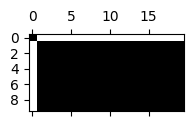

In [14]:
A_QE = np.vstack([Qv_op( A.T.dot( Qv_in(𝐞, 𝐯, i=0)), 𝐯, i=0) for 𝐞 in E.T])
plt.figure(figsize=(2,2));    plt.spy(np.around(A_QE[:,:20], 10));    plt.show()

The module also has matrix-matrix operator forms:

In [15]:
mA_QE = Qm_op( A.dot( Qm_in(E, v, i = 0) ), v, i=0)
np.allclose(mA_QE.T, A_QE)

True

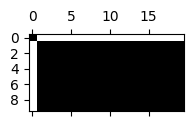

In [16]:
plt.figure(figsize=(2,2));    plt.spy(np.around(mA_QE.T[:,:20], 10));    plt.show()

---